# L3 —— 免疫细胞 细胞类型确认

In [1]:
import os, re
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import omicverse as ov

# 路径与文件
DATA_ROOT = "/mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data"
ANNO_DIR  = os.path.join(DATA_ROOT, "06_annotation/L3/immune"); os.makedirs(ANNO_DIR, exist_ok=True)
FIG_DIR   = os.path.join(ANNO_DIR, "figs");          os.makedirs(FIG_DIR,  exist_ok=True)
IN_PATH   = os.path.join(DATA_ROOT, "06_annotation/L2/L2_immune_annotated.h5ad")
OUT_H5AD  = os.path.join(ANNO_DIR, "L3_immune_annotated.h5ad")
OUT_CSV   = os.path.join(ANNO_DIR, "L3_immune_summary.csv")

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 数据读取

In [2]:
adata = sc.read_h5ad(IN_PATH)
adata

AnnData object with n_obs × n_vars = 187365 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'L1lin_conf', 'leiden_0.4', 'L2_marker', 'L2_score', 'L2_gpt', 'L2_celltype_sub', 'L2_celltype', 'L2_conf_methods', 'L2_stability', 'L2_conf', 'L2_votes'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [3]:
adata.obs.head()

,GSM,GSE,group,leiden_scVI_0.2,L1_lineage,L1lin_conf,leiden_0.4,L2_marker,L2_score,L2_gpt,L2_celltype_sub,L2_celltype,L2_conf_methods,L2_stability,L2_conf,L2_votes
GSM8980878_UC68_CELL270_N3,GSM8980878,GSE296969,UC,0,Immune,1.0,6,Myeloid,Myeloid,Myeloid,Myeloid,Immune|Myeloid,1.0,0.999954,0.999991,L2_marker+L2_score+L2_gpt
GSM8980878_UC68_CELL388_N3,GSM8980878,GSE296969,UC,0,Immune,1.0,9,Plasma,Plasma,Other,Plasma,Immune|Plasma,1.0,0.996630,0.999326,L2_marker+L2_score+L2_gpt
GSM8980878_UC68_CELL478_N2,GSM8980878,GSE296969,UC,0,Immune,1.0,0,Other,T_NK,T_NK,T_NK,Immune|T_NK,1.0,0.998137,0.999627,L2_marker+L2_score+L2_gpt
GSM8980878_UC68_CELL572_N2,GSM8980878,GSE296969,UC,0,Immune,1.0,5,Other,T_NK,Other,Other,Immune|Other,0.0,0.333333,0.066667,L2_marker+L2_score+L2_gpt
GSM8980878_UC68_CELL580_N5,GSM8980878,GSE296969,UC,4,Immune,1.0,3,B,B,B,B,Immune|B,1.0,0.980719,0.996144,L2_marker+L2_score+L2_gpt


In [4]:
obs_keep_candidates = [
    # 批次 & 来源
    "GSM", "GSE", "group",
    # L1 关键信息
    "leiden_scVI_0.2",
    "L1_lineage",
    "leiden_0.4",
    # L2 最终结果
    "L2_celltype_sub",        # 无前缀的子类
]
# 只保留实际存在的列
obs_keep = [c for c in obs_keep_candidates if c in adata.obs.columns]
adata.obs = adata.obs[obs_keep]
adata

AnnData object with n_obs × n_vars = 187365 × 11743
    obs: 'GSM', 'GSE', 'group', 'leiden_scVI_0.2', 'L1_lineage', 'leiden_0.4', 'L2_celltype_sub'
    var: 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'GSE_colors', 'L1_lineage_colors', 'L2_celltype_colors', 'REFERENCE_MANU', 'hvg', 'leiden_0.2', 'leiden_0.4', 'leiden_0.4_colors', 'leiden_0.6', 'leiden_scVI_0.2', 'leiden_scVI_0.2_colors', 'log1p', 'neighbors', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## 查看L2注释结果

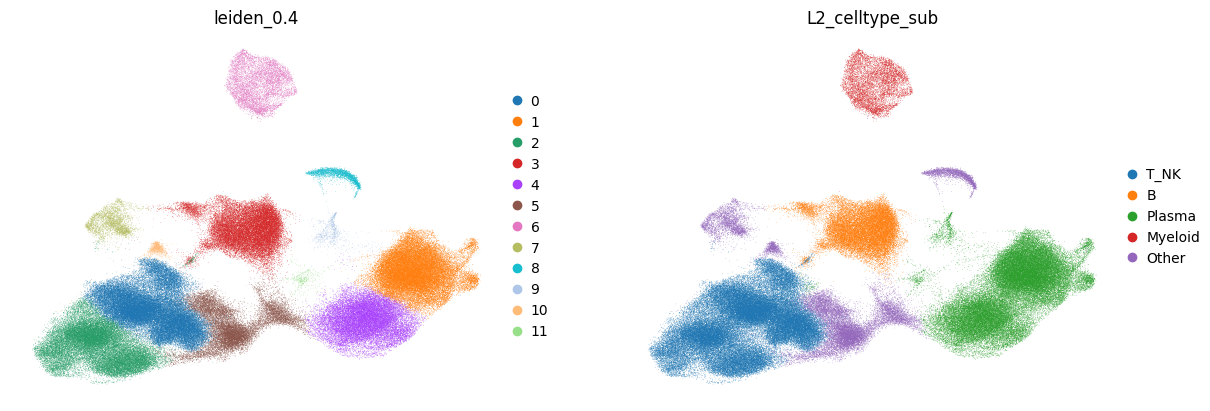

In [7]:
sc.pl.umap(adata,
           color=["leiden_0.4","L2_celltype_sub"],
           frameon=False,)

### T 细胞

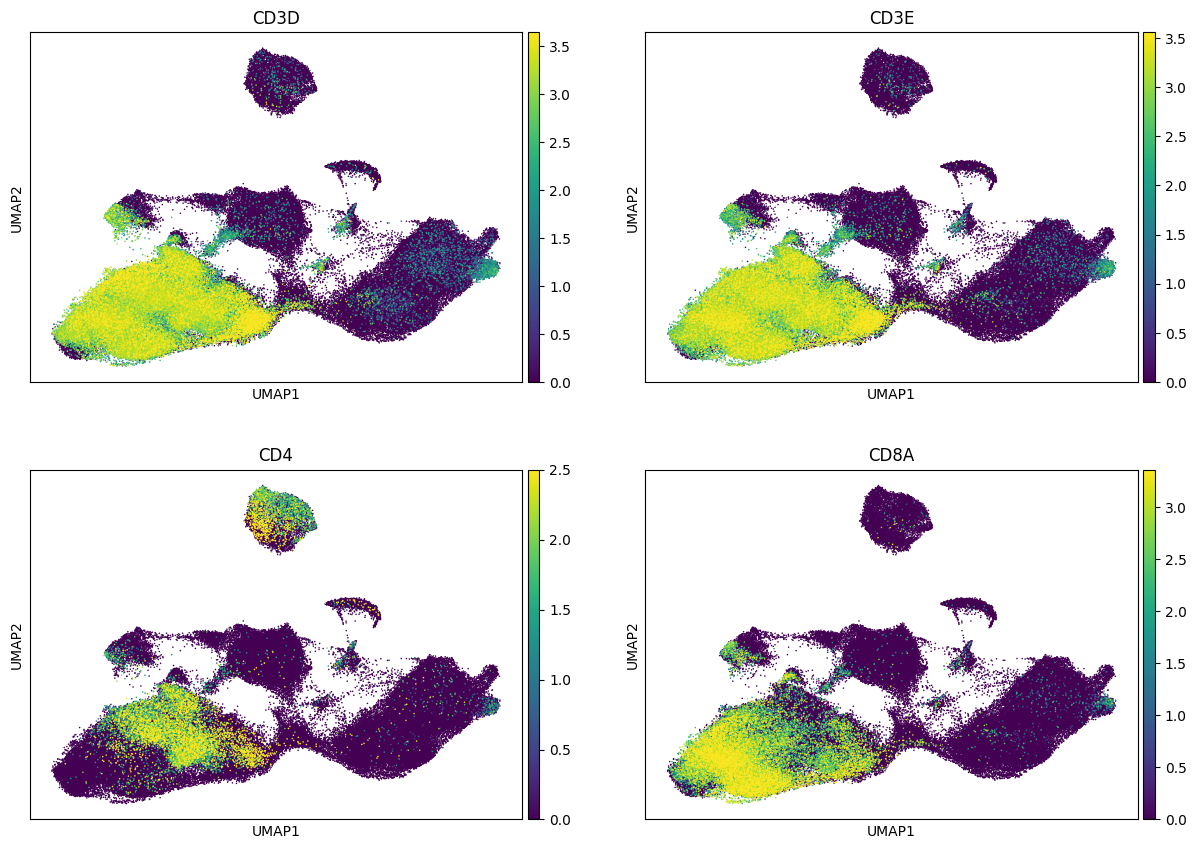

In [10]:
t_markers = ["CD3D", "CD3E", "CD4", "CD8A", 
               ]
def safe_genes(genes, adata):
    return [g for g in genes if g in adata.var_names]

sc.pl.umap(adata, color=safe_genes(t_markers, adata), ncols=2, cmap="viridis", vmax="p99", vmin=0, size=5,)

In [14]:
# 1. 定义需要修改的 leiden cluster 编号
# 注意：Scanpy 默认的 cluster 编号通常是字符串格式 ('5' 而不是 5)
target_clusters = ['5', '7', '10']

# 2. (推荐) 为了防止报错，先将 L2_celltype_sub 列转为字符串类型
# 如果该列已经是 object/string 类型，这一步没有任何副作用
adata.obs['L2_celltype_sub'] = adata.obs['L2_celltype_sub'].astype(str)

# 3. 使用 .loc 和 .isin 进行条件赋值
# 逻辑：在 obs 中找到 'leiden_0.4' 列包含在 target_clusters 里的行，将它们的 'L2_celltype_sub' 列改为 'T_NK'
adata.obs.loc[adata.obs['leiden_0.4'].isin(target_clusters), 'L2_celltype_sub'] = 'T_NK'

# 4. (可选) 修改完后，可以将该列转回 category 类型，以节省内存
adata.obs['L2_celltype_sub'] = adata.obs['L2_celltype_sub'].astype('category')

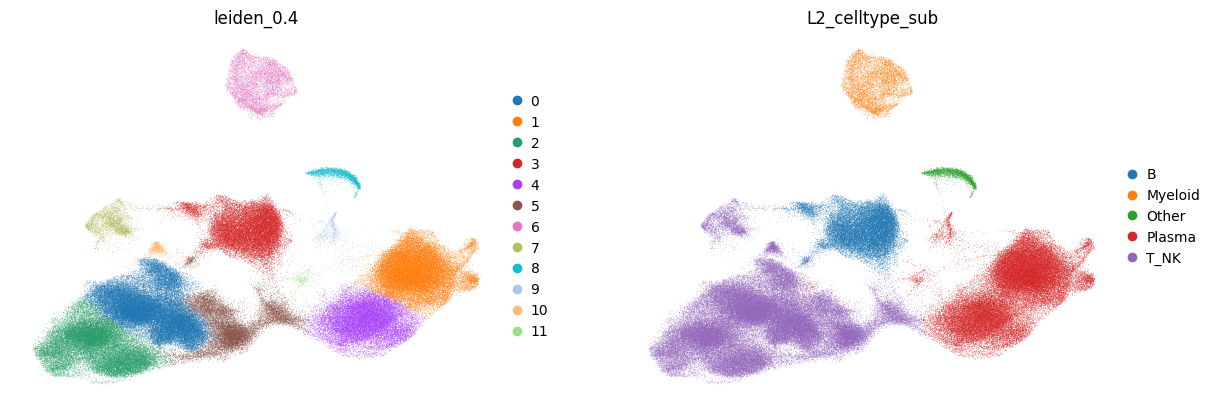

In [15]:
sc.pl.umap(adata,
           color=["leiden_0.4","L2_celltype_sub"],
           frameon=False,)

## 对Other群细胞做差异分析

In [16]:
sc.tl.rank_genes_groups(adata, groupby='L2_celltype_sub', groups=['Other'], reference='rest', method='wilcoxon')

In [17]:
# 直接提取 'Other' 组的差异分析结果表
df_other = sc.get.rank_genes_groups_df(adata, group='Other')

# 筛选更有意义的 Marker 基因
# 标准通常是：对数倍数变化 (logfoldchanges) > 1 且 调整后P值 (pvals_adj) < 0.05
# 这里的 logfoldchanges > 1 大约意味着表达量是背景的 2 倍以上 (2^1)
filtered_markers = df_other[(df_other['logfoldchanges'] > 1) & (df_other['pvals_adj'] < 0.05)]

# 查看前 20 个显著高表达的基因
print(filtered_markers[['names', 'scores', 'logfoldchanges', 'pvals_adj']].head(20))

      names     scores  logfoldchanges  pvals_adj
0     ANXA1  69.743767        4.405022        0.0
1      CD63  62.750233        3.214931        0.0
2    S100A6  61.326042        2.847876        0.0
3     VWA5A  58.700462        8.514904        0.0
4      FTH1  57.524994        1.877912        0.0
5       CD9  57.002163        5.292510        0.0
6    FCER1G  54.851013        5.377861        0.0
7       UBB  54.304699        1.670420        0.0
8      GLUL  54.160122        5.934492        0.0
9   LAPTM4A  53.570503        3.647185        0.0
10     CAPG  50.720074        3.983936        0.0
11      CLU  50.673672        7.671354        0.0
12     SRGN  49.344395        1.742150        0.0
13     RPL7  48.693172        1.359008        0.0
14      FTL  47.043221        1.098512        0.0
15   NFKBIA  46.768379        2.254666        0.0
16     LMNA  45.100475        3.111330        0.0
17      VIM  45.026001        1.859414        0.0
18    H3F3B  43.784187        1.197921        0.0


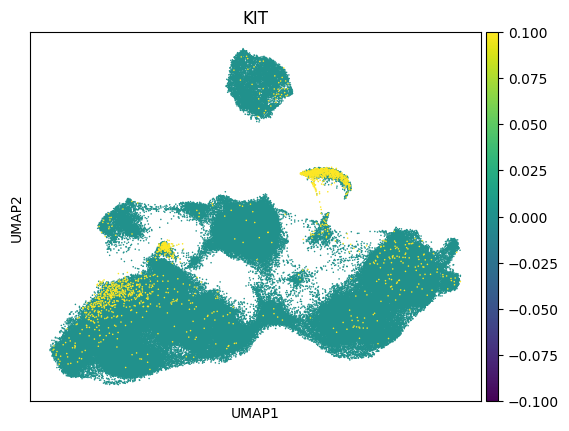

In [20]:
mast_markers = ['TPSAB1', 'TPSB2', 'CPA3', 'CMA1','KIT', 'FCER1A', 'MS4A2', 'HDC']
sc.pl.umap(adata, color=safe_genes(mast_markers, adata), ncols=2, cmap="viridis", vmax="p99", vmin=0, size=5,)

In [21]:
# 1. 定义需要修改的 leiden cluster 编号
# 注意：Scanpy 默认的 cluster 编号通常是字符串格式 ('5' 而不是 5)
target_clusters = ['8']

# 2. (推荐) 为了防止报错，先将 L2_celltype_sub 列转为字符串类型
# 如果该列已经是 object/string 类型，这一步没有任何副作用
adata.obs['L2_celltype_sub'] = adata.obs['L2_celltype_sub'].astype(str)

# 3. 使用 .loc 和 .isin 进行条件赋值
# 逻辑：在 obs 中找到 'leiden_0.4' 列包含在 target_clusters 里的行，将它们的 'L2_celltype_sub' 列改为 'T_NK'
adata.obs.loc[adata.obs['leiden_0.4'].isin(target_clusters), 'L2_celltype_sub'] = 'Mast'

# 4. (可选) 修改完后，可以将该列转回 category 类型，以节省内存
adata.obs['L2_celltype_sub'] = adata.obs['L2_celltype_sub'].astype('category')

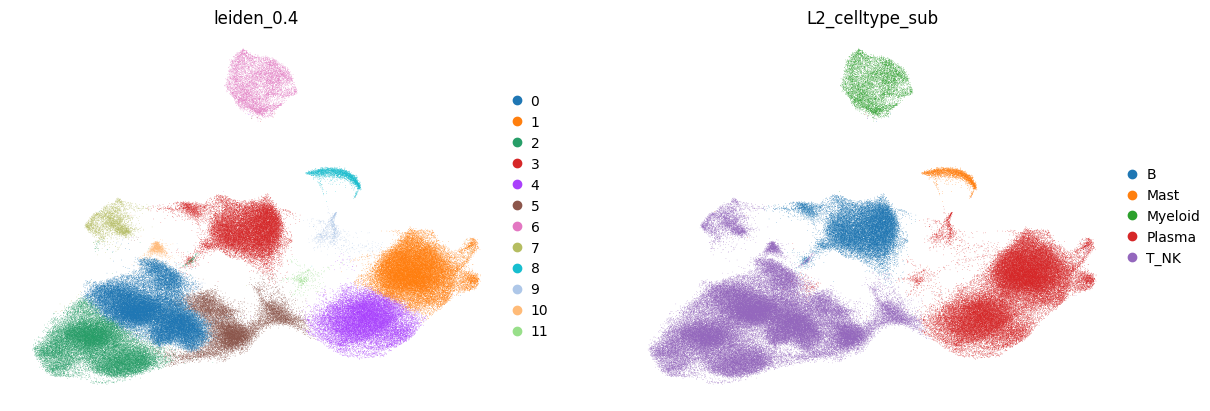

In [22]:
sc.pl.umap(adata,
           color=["leiden_0.4","L2_celltype_sub"],
           frameon=False,)

## 保存

In [25]:
import os
import matplotlib.pyplot as plt

# 绘制并保存 UMAP 图
fig_path = os.path.join(FIG_DIR, "L2_Immune_annotation_UMAP.png")

sc.pl.umap(
    adata,
    color=["L2_celltype_sub"],
    frameon=False,
    title="L2 Immune Lineage Annotation",  # 英文标题
    save=None,  # 我们手动保存，不用 Scanpy 自动保存
    show=False  # 防止 Notebook 中立即弹出
)

# 手动保存图片（可控格式和分辨率）
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"[Saved figure] → {fig_path}")


[Saved figure] → /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/immune/figs/L2_Immune_annotation_UMAP.png


In [23]:
wanted_cols = [
    "GSM", "GSE", "group",
    "L1_lineage"             
    "L2_celltype_sub",        # 最终子类（回收后已含 Other）
]
out_cols = [c for c in wanted_cols if c in adata.obs.columns]

adata.obs[out_cols].to_csv(OUT_CSV, index=True)
print(f"[Saved per-cell table] -> {OUT_CSV}")

[Saved per-cell table] -> /mnt/c/Users/Future/OneDrive/UC_project/scRNA-seq_data/06_annotation/L3/immune/L3_immune_summary.csv


In [24]:
adata.write_h5ad(OUT_H5AD, compression="gzip")